<a href="https://colab.research.google.com/github/akash-321/hate-speech-detection-RAG/blob/main/notebooks/model_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Two Models Comparison mymodel and IMSyPP

In [9]:
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

SEED = 42
np.random.seed(SEED)

In [12]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = "/content/drive/MyDrive/dissertation"
os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

FIG_DIR = "/content/drive/MyDrive/dissertation/figures"
import os; os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(name):
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/{name}.png", dpi=200, bbox_inches="tight")
    plt.show()

### Reading the test of mymodel


In [15]:
import pandas as pd

test_c = pd.read_csv("/content/drive/MyDrive/dissertation/test_with_my_predictions.csv")

print("Number of test comments:", len(test_c))

Number of test comments: 1084


### Running IMSyPP and save it.

In [16]:
from transformers import pipeline


imsypp = pipeline("text-classification", model="IMSyPP/hate_speech_en", truncation=True)

mapping = {"LABEL_0": 0, "LABEL_1": 1, "LABEL_2": 1, "LABEL_3": 1}

predictions = []
for text in test_c["text"]:
    result = imsypp(str(text))[0]
    predictions.append(mapping[result["label"]])

test_c["imsypp_pred"] = predictions

test_c.to_csv("test_predictions_both_models.csv", index=False)

config.json:   0%|          | 0.00/865 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

### Confusion matrix heatmap

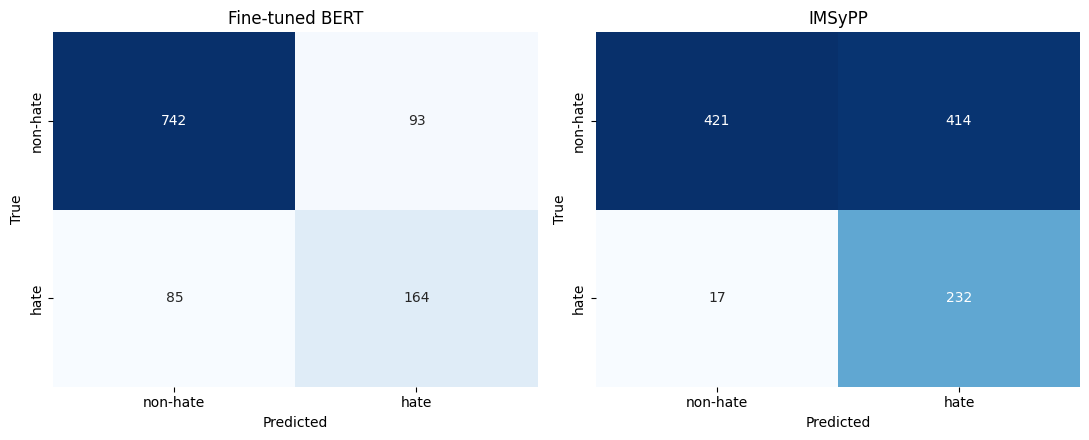

In [25]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, col) in zip(axes, [("Fine-tuned BERT", "my_pred_bin"),
                                  ("IMSyPP", "imsypp_pred")]):
    cm = confusion_matrix(test_c["label_bin"], test_c[col])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["non-hate", "hate"], yticklabels=["non-hate", "hate"], ax=ax)
    ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
save_fig("confusion_matrices")

### Comparison of the models

In [17]:
from sklearn.metrics import accuracy_score, f1_score

true_labels = test_c["label_bin"]

print("My model - accuracy:", round(accuracy_score(true_labels, test_c["my_pred_bin"]), 4))
print("My model - F1 score:", round(f1_score(true_labels, test_c["my_pred_bin"]), 4))
print("IMSyPP - accuracy:", round(accuracy_score(true_labels, test_c["imsypp_pred"]), 4))
print("IMSyPP - F1 score:", round(f1_score(true_labels, test_c["imsypp_pred"]), 4))

My model - accuracy: 0.8358
My model - F1 score: 0.6482
IMSyPP - accuracy: 0.6024
IMSyPP - F1 score: 0.5184


### Accuracy comparison by religion

In [18]:
rows = []
for religion in test_c["target_group"].unique():
    subset = test_c[test_c["target_group"] == religion]
    rows.append({
        "religion": religion.replace("target_religion_", ""),
        "n_comments": len(subset),
        "n_hate": int(subset["label_bin"].sum()),
        "my_model": round(accuracy_score(subset["label_bin"], subset["my_pred_bin"]), 4),
        "imsypp": round(accuracy_score(subset["label_bin"], subset["imsypp_pred"]), 4),
    })

group_accuracy = pd.DataFrame(rows).sort_values("my_model")
group_accuracy

,religion,n_comments,n_hate,my_model,imsypp
2,jewish,172,51,0.7791,0.5465
0,muslim,510,134,0.8275,0.6216
3,christian,362,56,0.8646,0.6133
1,atheist,36,7,0.9167,0.4722
4,buddhist,4,1,1.0000,0.7500


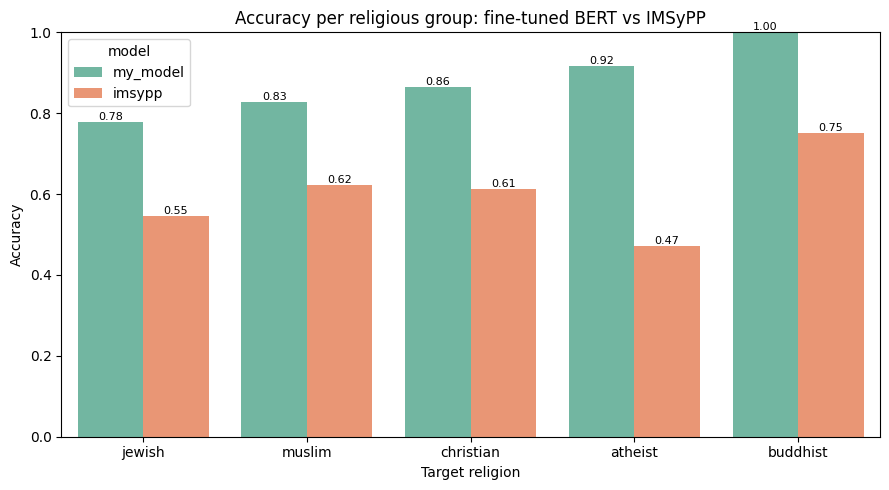

In [19]:
plot_df = group_accuracy.melt(id_vars=["religion", "n_comments"],
                              value_vars=["my_model", "imsypp"],
                              var_name="model", value_name="accuracy")

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=plot_df, x="religion", y="accuracy", hue="model", palette="Set2")
ax.set_ylim(0, 1)
ax.set_xlabel("Target religion"); ax.set_ylabel("Accuracy")
ax.set_title("Accuracy per religious group: fine-tuned BERT vs IMSyPP")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8)
save_fig("accuracy_per_group")

### FPR and FNR comparison of both models

In [20]:
rows = []
for religion in test_c["target_group"].unique():
    subset = test_c[test_c["target_group"] == religion]

    for model_name, pred_col in [("MyModel", "my_pred_bin"), ("IMSyPP", "imsypp_pred")]:
        true = subset["label_bin"]
        pred = subset[pred_col]

        false_positives = ((true == 0) & (pred == 1)).sum()
        true_negatives = ((true == 0) & (pred == 0)).sum()
        false_negatives = ((true == 1) & (pred == 0)).sum()
        true_positives = ((true == 1) & (pred == 1)).sum()

        fpr = false_positives / (false_positives + true_negatives)
        fnr = false_negatives / (false_negatives + true_positives)

        rows.append({"religion": religion.replace("target_religion_", ""),
                     "model": model_name,
                     "FPR": round(fpr, 4),
                     "FNR": round(fnr, 4)})

fairness_table = pd.DataFrame(rows)
fairness_table

,religion,model,FPR,FNR
0,muslim,MyModel,0.1090,0.3507
1,muslim,IMSyPP,0.4894,0.0672
2,atheist,MyModel,0.0690,0.1429
3,atheist,IMSyPP,0.6552,0.0000
4,jewish,MyModel,0.1570,0.3725
5,jewish,IMSyPP,0.5868,0.1373
6,christian,MyModel,0.1013,0.3214
7,christian,IMSyPP,0.4542,0.0179
8,buddhist,MyModel,0.0000,0.0000
9,buddhist,IMSyPP,0.3333,0.0000


### FPR/FNR bars

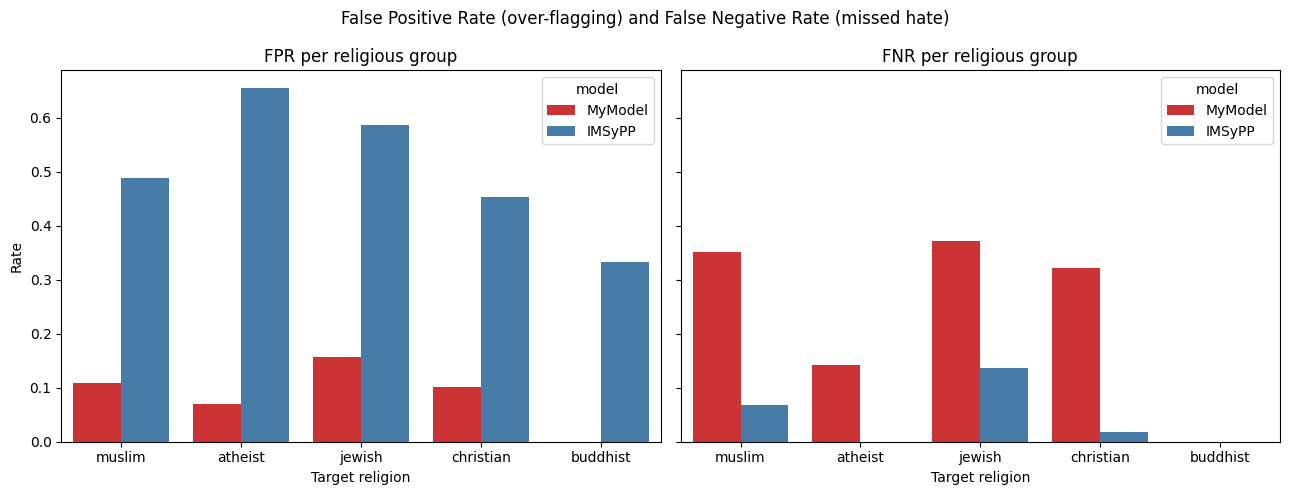

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, metric in zip(axes, ["FPR", "FNR"]):
    sns.barplot(data=fairness_table, x="religion", y=metric, hue="model",
                palette="Set1", ax=ax)
    ax.set_title(f"{metric} per religious group")
    ax.set_xlabel("Target religion")
axes[0].set_ylabel("Rate")
plt.suptitle("False Positive Rate (over-flagging) and False Negative Rate (missed hate)")
save_fig("fpr_fnr_per_group")

In [21]:
for model_name in ["MyModel", "IMSyPP"]:
    part = fairness_table[fairness_table["model"] == model_name]
    print(model_name)
    print(" FPR gap:", round(part["FPR"].max() - part["FPR"].min(), 4))
    print(" FNR gap:", round(part["FNR"].max() - part["FNR"].min(), 4))

MyModel
 FPR gap: 0.157
 FNR gap: 0.3725
IMSyPP
 FPR gap: 0.3219
 FNR gap: 0.1373


### Errors that each models made.

In [22]:
test_c["my_model_wrong"] = test_c["my_pred_bin"] != test_c["label_bin"]
test_c["imsypp_wrong"]   = test_c["imsypp_pred"] != test_c["label_bin"]

both_wrong  = test_c[test_c["my_model_wrong"] & test_c["imsypp_wrong"]]
only_mine   = test_c[test_c["my_model_wrong"] & ~test_c["imsypp_wrong"]]
only_imsypp = test_c[~test_c["my_model_wrong"] & test_c["imsypp_wrong"]]

print("Both models wrong:", len(both_wrong))
print("Only my model wrong:", len(only_mine))
print("Only IMSyPP wrong:", len(only_imsypp))

Both models wrong: 97
Only my model wrong: 81
Only IMSyPP wrong: 334


### Saving examples to read manually.

In [23]:
weak_groups = group_accuracy.head(2)["religion"].tolist()
weak_groups = ["target_religion_" + g for g in weak_groups]

all_errors = test_c[(test_c["my_model_wrong"] | test_c["imsypp_wrong"])
                    & test_c["target_group"].isin(weak_groups)]

samples = []
for religion in weak_groups:
    group_errors = all_errors[all_errors["target_group"] == religion]
    n = max(1, len(group_errors) // 3)
    samples.append(group_errors.sample(n=n, random_state=42))

qualitative_sample = pd.concat(samples)
qualitative_sample.to_csv("qualitative_errors_sample.csv", index=False)
print("Saved", len(qualitative_sample), "examples to read manually")

Saved 110 examples to read manually
